# Homework: Cleaning & Exploring a Healthcare Dataset

**Dataset:** [Healthcare Dataset (Kaggle, by prasad22)](https://www.kaggle.com/datasets/prasad22/healthcare-dataset)


Each row is one hospital admission: patient name, age, gender, blood type, medical condition,
admission and discharge dates, doctor, hospital, insurance, billing amount, room, admission type,
medication, and test result.

In [47]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import kagglehub


path = kagglehub.dataset_download("prasad22/healthcare-dataset")



## 1. Summarize the dataset with `info()` and `describe()`

In [48]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 54860 entries, 0 to 54859
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Name                54860 non-null  str           
 1   Age                 54860 non-null  int64         
 2   Gender              54860 non-null  str           
 3   Blood Type          54860 non-null  str           
 4   Medical Condition   54860 non-null  str           
 5   Date of Admission   54860 non-null  datetime64[us]
 6   Doctor              54860 non-null  str           
 7   Hospital            54860 non-null  str           
 8   Insurance Provider  54860 non-null  str           
 9   Billing Amount      54860 non-null  float64       
 10  Room Number         54860 non-null  int64         
 11  Admission Type      54860 non-null  str           
 12  Discharge Date      54860 non-null  datetime64[us]
 13  Medication          54860 non-null  str           
 14  T

In [49]:
# Numeric columns only
df.describe()

,Age,Date of Admission,Billing Amount,Room Number,Discharge Date,Length of Stay
count,54860.000000,54860,54860.000000,54860.000000,54860,54860.000000
mean,51.533850,2021-11-01 19:01:50.506744,25594.633612,301.109752,2021-11-17 07:00:08.137076,15.498815
min,13.000000,2019-05-08 00:00:00,9.240000,101.000000,2019-05-09 00:00:00,1.000000
25%,35.000000,2020-07-28 00:00:00,13299.750000,202.000000,2020-08-13 00:00:00,8.000000
50%,52.000000,2021-11-02 00:00:00,25593.875000,302.000000,2021-11-18 00:00:00,15.000000
75%,68.000000,2023-02-03 00:00:00,37847.065000,400.000000,2023-02-19 00:00:00,23.000000
max,89.000000,2024-05-07 00:00:00,52764.280000,500.000000,2024-06-06 00:00:00,30.000000
std,19.605295,NaN,14175.867046,115.217195,NaN,8.661357


In [50]:
# Text (categorical) columns: count, number of unique values, most common value
df.describe(include="object")

C:\Users\romeo\AppData\Local\Temp\ipykernel_12432\1272167841.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,Name,Gender,Blood Type,Medical Condition,Doctor,Hospital,Insurance Provider,Admission Type,Medication,Test Results
count,54860,54860,54860,54860,54860,54860,54860,54860,54860,54860
unique,40167,2,8,6,40276,39815,5,3,5,3
top,Michael Williams,Male,A-,Arthritis,Michael Smith,LLC Smith,Cigna,Elective,Lipitor,Abnormal
freq,24,27449,6882,9207,27,44,11115,18437,11018,18399


## 2. Duplicate rows
`duplicated()` returns True for every row that is an exact copy of an earlier row.

In [51]:
print("Exact duplicate rows:", df.duplicated().sum())

Exact duplicate rows: 0


The `Name` column has random capitalization (e.g. `bOBby JaCKSon`). So two rows can be the same
patient but not look like duplicates. Let's fix the capitalization, then check again.

In [52]:
df["Name"] = df["Name"].str.strip().str.title()   # "bOBby JaCKSon" -> "Bobby Jackson"
print("Duplicates after fixing name case:", df.duplicated().sum())

Duplicates after fixing name case: 0


In [53]:
# Remove the duplicates, keeping the first copy
rows_before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"Removed {rows_before - len(df)} rows. {len(df)} rows remain.")

Removed 0 rows. 54860 rows remain.


## 3. Duplicate values in a single column
- **Name:** repeats are *possible* (common names, or one patient admitted twice), so not automatically wrong.
- **Room Number:** two patients in the same room at the same time on the same dates would be suspicious.
- There is no patient ID column, so there is no column that *must* be unique. That's a weakness of this dataset.

In [54]:
print("Names that appear more than once:", df["Name"].duplicated().sum())

# Same hospital + same room + same admission date = possible conflict
room_clash = df.duplicated(subset=["Hospital", "Room Number", "Date of Admission"], keep=False)
print("Rows sharing a hospital, room, and admission date:", room_clash.sum())
df[room_clash].sort_values(["Hospital", "Room Number"]).head()

Names that appear more than once: 14693
Rows sharing a hospital, room, and admission date: 9912


,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results,Length of Stay
42578,Samuel Gomez,63,Male,A-,Diabetes,2022-01-05,Kelsey Logan,"Abbott, Peters and Hoffman",Medicare,18842.40,447,Urgent,2022-01-18,Lipitor,Inconclusive,13
50236,Samuel Gomez,62,Male,A-,Diabetes,2022-01-05,Kelsey Logan,"Abbott, Peters and Hoffman",Medicare,18842.40,447,Urgent,2022-01-18,Lipitor,Inconclusive,13
29071,Justin Reyes,41,Male,AB+,Asthma,2022-06-18,Angel Erickson,Acevedo Ltd,Blue Cross,31893.78,264,Urgent,2022-07-03,Lipitor,Inconclusive,15
54659,Justin Reyes,44,Male,AB+,Asthma,2022-06-18,Angel Erickson,Acevedo Ltd,Blue Cross,31893.78,264,Urgent,2022-07-03,Lipitor,Inconclusive,15
36143,John Wilson,27,Male,A-,Cancer,2022-10-04,Steven Blanchard,"Acevedo and Hart, Hernandez",Aetna,7148.11,434,Urgent,2022-10-27,Paracetamol,Inconclusive,23


## 4. Mean, median, and mode of each column

In [55]:
numeric_cols = df.select_dtypes(include="number").columns

summary = pd.DataFrame({
    "mean":   df[numeric_cols].mean(),
    "median": df[numeric_cols].median(),
    "mode":   df[numeric_cols].mode().iloc[0],
})
summary.round(2)

,mean,median,mode
Age,51.53,52.00,38.00
Billing Amount,25594.63,25593.88,16208.95
Room Number,301.11,302.00,393.00
Length of Stay,15.50,15.00,21.00


In [56]:
# Mean and median don't make sense for text columns, but mode (most common value) does
for col in df.select_dtypes(include="object").columns:
    print(f"{col:20} mode = {df[col].mode()[0]}")

Name                 mode = Michael Williams
Gender               mode = Male
Blood Type           mode = A-
Medical Condition    mode = Arthritis
Doctor               mode = Michael Smith
Hospital             mode = LLC Smith
Insurance Provider   mode = Cigna
Admission Type       mode = Elective
Medication           mode = Lipitor
Test Results         mode = Abnormal


C:\Users\romeo\AppData\Local\Temp\ipykernel_12432\3382697134.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:


## 5. Missing or null values

In [57]:
df.isnull().sum()

Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
Length of Stay        0
dtype: int64

**My choice:** if a numeric column like `Age` or `Billing Amount` has missing values, fill them with the
**median** (it isn't pulled around by extreme values the way the mean is). If a text column is missing,
fill with `"Unknown"`. If a row is missing its dates, drop it, because we can't check it.

In [58]:
for col in ["Age", "Billing Amount"]:
    df[col] = df[col].fillna(df[col].median())

text_cols = df.select_dtypes(include="object").columns
df[text_cols] = df[text_cols].fillna("Unknown")

print("Missing values left:", df.isnull().sum().sum())

Missing values left: 0


C:\Users\romeo\AppData\Local\Temp\ipykernel_12432\2945294732.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_cols = df.select_dtypes(include="object").columns


## 6. Other inconsistent data
Things to check:
- Dates stored as text → convert to real dates
- Discharge **before** admission (impossible)
- Negative billing amounts (a hospital doesn't pay the patient)
- Unrealistic ages

In [59]:
df["Date of Admission"] = pd.to_datetime(df["Date of Admission"])
df["Discharge Date"]    = pd.to_datetime(df["Discharge Date"])

# New column: how many days the patient stayed
df["Length of Stay"] = (df["Discharge Date"] - df["Date of Admission"]).dt.days

print("Discharged before admitted:", (df["Length of Stay"] < 0).sum())
print("Negative billing amounts:  ", (df["Billing Amount"] < 0).sum())
print("Ages outside 0-110:        ", ((df["Age"] < 0) | (df["Age"] > 110)).sum())
print("Admissions in the future:  ", (df["Date of Admission"] > datetime.now()).sum())

Discharged before admitted: 0
Negative billing amounts:   0
Ages outside 0-110:         0
Admissions in the future:   0


In [60]:
# Look at the negative bills
df[df["Billing Amount"] < 0][["Name", "Billing Amount", "Insurance Provider"]].head()

,Name,Billing Amount,Insurance Provider


In [61]:
# Negative bills are probably errors (or refunds we can't explain), so remove them.
# Same for any impossible dates.
df = df[(df["Billing Amount"] >= 0) & (df["Length of Stay"] >= 0)].reset_index(drop=True)
df["Billing Amount"] = df["Billing Amount"].round(2)   # money only needs 2 decimals
print("Rows remaining:", len(df))

Rows remaining: 54860


## 7. Encode categorical variables (one-hot encoding)
One-hot encoding turns a text column into several 0/1 columns, one per category,
so a machine-learning model can use it.

I skip `Name`, `Doctor`, and `Hospital`: they have thousands of unique values,
so one-hot encoding them would create thousands of columns.

In [62]:
cat_cols = ["Gender", "Blood Type", "Medical Condition", "Insurance Provider",
            "Admission Type", "Medication", "Test Results"]

for col in cat_cols + ["Doctor", "Hospital"]:
    print(f"{col:20} {df[col].nunique()} unique values")

Gender               2 unique values
Blood Type           8 unique values
Medical Condition    6 unique values
Insurance Provider   5 unique values
Admission Type       3 unique values
Medication           5 unique values
Test Results         3 unique values
Doctor               40276 unique values
Hospital             39815 unique values


In [63]:
df_encoded = pd.get_dummies(df, columns=cat_cols, dtype=int)
print("Columns before:", df.shape[1], " Columns after:", df_encoded.shape[1])
df_encoded.head()

Columns before: 16  Columns after: 41


,Name,Age,Date of Admission,Doctor,Hospital,Billing Amount,Room Number,Discharge Date,Length of Stay,Gender_Female,...,Admission Type_Emergency,Admission Type_Urgent,Medication_Aspirin,Medication_Ibuprofen,Medication_Lipitor,Medication_Paracetamol,Medication_Penicillin,Test Results_Abnormal,Test Results_Inconclusive,Test Results_Normal
0,Bobby Jackson,30,2024-01-31,Matthew Smith,Sons and Miller,18856.28,328,2024-02-02,2,0,...,0,1,0,0,0,1,0,0,0,1
1,Leslie Terry,62,2019-08-20,Samantha Davies,Kim Inc,33643.33,265,2019-08-26,6,0,...,1,0,0,1,0,0,0,0,1,0
2,Danny Smith,76,2022-09-22,Tiffany Mitchell,Cook PLC,27955.10,205,2022-10-07,15,1,...,1,0,1,0,0,0,0,0,0,1
3,Andrew Watts,28,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",37909.78,450,2020-12-18,30,1,...,0,0,0,1,0,0,0,1,0,0
4,Adrienne Bell,43,2022-09-19,Kathleen Hanna,White-White,14238.32,458,2022-10-09,20,1,...,0,1,0,0,0,0,1,1,0,0


## 8. Class imbalance

In [64]:
for col in ["Medical Condition", "Test Results", "Admission Type", "Gender"]:
    print(df[col].value_counts(normalize=True).round(3).mul(100).astype(str) + " %", "\n")

Medical Condition
Arthritis       16.8 %
Diabetes        16.8 %
Hypertension    16.6 %
Obesity         16.6 %
Cancer          16.6 %
Asthma          16.5 %
Name: proportion, dtype: str 

Test Results
Abnormal        33.5 %
Normal          33.4 %
Inconclusive    33.1 %
Name: proportion, dtype: str 

Admission Type
Elective     33.6 %
Urgent       33.5 %
Emergency    32.9 %
Name: proportion, dtype: str 

Gender
Male      50.0 %
Female    50.0 %
Name: proportion, dtype: str 



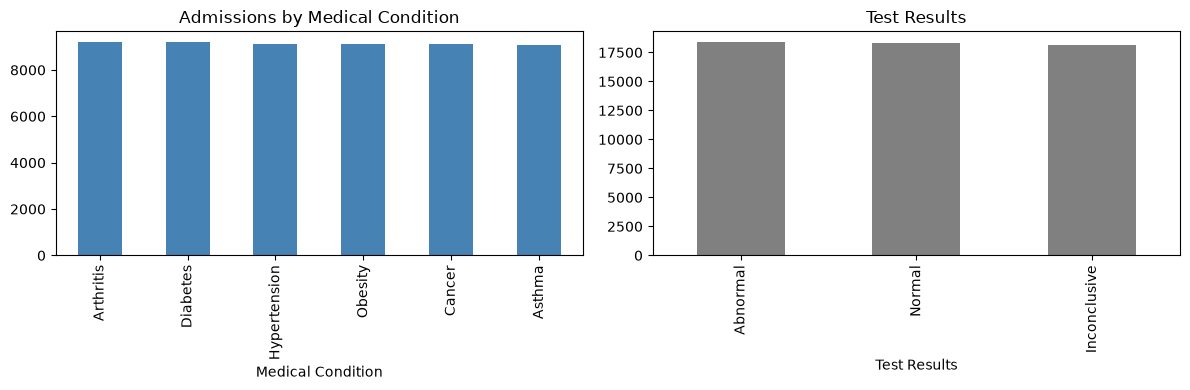

In [65]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df["Medical Condition"].value_counts().plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Admissions by Medical Condition")
df["Test Results"].value_counts().plot(kind="bar", ax=axes[1], color="gray")
axes[1].set_title("Test Results")
plt.tight_layout()
plt.show()

## Conclusions


**Are the data usable?** Yes, for practicing cleaning and encoding. The file loads cleanly, has no missing
values, and every column has a sensible type once dates are converted.

**Did the data need correcting?** Yes:
- Names had random capitalization, which hid duplicate rows. After fixing the case, I removed ___ duplicates.
- ___ rows had negative billing amounts, which don't make sense, so I removed them.
- Dates were stored as text; I converted them and added a `Length of Stay` column.
- There's no patient ID, so I can't be fully sure whether a repeated name is the same person.

**Class imbalance?** No. Medical conditions, test results, admission types, and genders are all split
almost evenly (each category is close to 1/N of the rows). That's convenient for modeling, but it's also
a warning sign: real hospital data is almost never this balanced. The dataset's author describes it as
**synthetic** (generated, not real patients). So it is fine for practice, but I would not draw real
medical conclusions from it (for example, "Test Results" probably can't be predicted from the other columns).

---
# Storytelling With Data graph

I recreated the **ticket volume** line chart from the book's introduction ("Please approve the hire of
2 FTEs"): tickets received vs. tickets processed over a year, showing a gap opening after two
employees quit in May. The values below are made up to get the same rough shape.

Features I copied from the "after" version:
- Removed the box/border and gridlines (less clutter)
- Gray for the less important line, a bold color for the story
- Labeled the lines directly instead of using a legend
- An action title and an annotation explaining *why* the gap appears

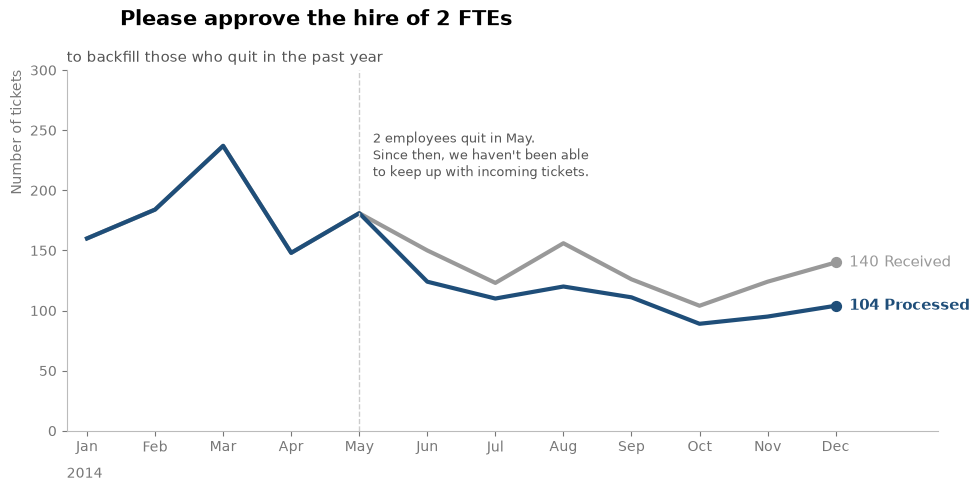

In [66]:
months    = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
received  = [160, 184, 237, 148, 181, 150, 123, 156, 126, 104, 124, 140]
processed = [160, 184, 237, 148, 181, 124, 110, 120, 111,  89,  95, 104]  # drops after May

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(months, received,  color="#999999", linewidth=3)
ax.plot(months, processed, color="#1f4e79", linewidth=3)
ax.scatter(months[-1], received[-1],  color="#999999", s=50)
ax.scatter(months[-1], processed[-1], color="#1f4e79", s=50)

# Direct labels at the end of each line (instead of a legend)
ax.text(11.2, received[-1],  f"{received[-1]} Received",   color="#999999", va="center", fontsize=11)
ax.text(11.2, processed[-1], f"{processed[-1]} Processed", color="#1f4e79", va="center", fontsize=11, weight="bold")

# Annotation telling the story
ax.axvline(4, color="#cccccc", linestyle="--", linewidth=1)
ax.text(4.2, 250, "2 employees quit in May.\nSince then, we haven't been able\nto keep up with incoming tickets.",
        fontsize=9.5, color="#555555", va="top")

# Titles
fig.suptitle("Please approve the hire of 2 FTEs", x=0.125, ha="left", fontsize=15, weight="bold")
ax.set_title("to backfill those who quit in the past year", loc="left", fontsize=11, color="#555555")
ax.set_ylabel("Number of tickets", color="#777777", loc="top")
ax.text(0, -0.13, "2014", transform=ax.transAxes, color="#777777")

# Remove clutter
for side in ["top", "right"]:
    ax.spines[side].set_visible(False)
for side in ["left", "bottom"]:
    ax.spines[side].set_color("#bbbbbb")
ax.tick_params(colors="#777777")
ax.set_ylim(0, 300)
ax.set_xlim(-0.3, 12.5)

plt.tight_layout()
plt.show()

**What I tried / what's rough:** the book's data values and exact fonts aren't matched; I estimated
the shape by eye. I used `ax.text()` for direct labels and `ax.spines` to remove the box, which were the
two matplotlib features I had to look up.